In [1]:
#@markdown ---------------
#@markdown ## **⚠️❗ Ejecute esta celda para descargar Shoes dataset❗⚠️**
#@markdown ### Esta celda creará la carpeta ```/content/shoes_data```

!pip install -qq gdown
!gdown -qq "https://drive.google.com/uc?id=1_fIMm5nPp0BLJZKfkJZ_juRmLpRK4iA0" -O /shoes_data.zip
!mkdir /content/shoes_data/
!unzip -qq /shoes_data.zip -d /content/shoes_data
!rm -r /shoes_data.zip
print ("Done!")
#@markdown ---------------

Done!


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image #los objetos estan basados en los objetos de torch
from tqdm import tqdm

import torch
from torch import nn
from torchsummary import summary
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [5]:
image_transforms = transforms.Compose([transforms.Resize((64,64), Image.BICUBIC),
                                       transforms.RandomPerspective(distortion_scale=0.6, p=0.5),
                                       transforms.RandomVerticalFlip(p=0.5),
                                       transforms.ToTensor()])

In [9]:
#---- Importar librerias. Incluya acá todas las librerías que requiera
train_dataset = datasets.ImageFolder(root= "/content/shoes_data/train/" , transform = image_transforms )
test_dataset = datasets.ImageFolder(root= "/content/shoes_data/test/" , transform = image_transforms )

train_loader = DataLoader(train_dataset, batch_size = 50 , shuffle=True)
test_loader = DataLoader(test_dataset, batch_size = 50 )

In [10]:
#---- Introduzca su codigo aqui. Puede utilizar cuantas celdas de código considere necesarias

# grab a batch from both training and validation dataloader
trainBatch = next(iter(train_loader))
valBatch = next(iter(test_loader))

In [12]:
print (trainBatch[1].shape, valBatch[0].shape) #train... son las etiquetas y valBacht son las imagenes

torch.Size([50]) torch.Size([50, 3, 64, 64])


In [31]:
model = nn.Sequential( #hasta en 4 dimensiones se puede hacer convulacion
    nn.Conv2d( 3 , 8 , kernel_size = (3,3) , padding = 1 ), nn.MaxPool2d(kernel_size = (2,2) ), nn.ReLU(), #numero de canales de entrada o de filtros que tiene mi imagen - segundo parameter numero de canales de salida en funcion de las potencias de 2
    nn.Conv2d( 8 , 16 , kernel_size = (3,3) , padding = 1 ), nn.MaxPool2d(kernel_size = (2,2) ), nn.ReLU(), #max pool de 2 generalmente ese val se usa lo tipico el kernel de 2x2
    nn.Conv2d( 16 , 32 , kernel_size = (3,3) , padding = 1 ), nn.MaxPool2d(kernel_size = (2,2) ), nn.ReLU(), #el submuestreo lo que hace es reducir el tamana no la matriz
    nn.Flatten(), #aplanar a vector o tensor
    nn.Linear( 32 * 8 * 8, 1024 ), nn.ReLU(), #ir reducciendo hasta llegar al menor numero de clases
    nn.Linear( 1024 , 512 ), nn.ReLU(),
    nn.Linear( 512 , 256 ), nn.ReLU(),
    nn.Linear( 256 , 3 ), nn.Softmax()
)

model.cuda()
summary(model, input_size=( 3,64,64 ))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 8, 64, 64]             224
         MaxPool2d-2            [-1, 8, 32, 32]               0
              ReLU-3            [-1, 8, 32, 32]               0
            Conv2d-4           [-1, 16, 32, 32]           1,168
         MaxPool2d-5           [-1, 16, 16, 16]               0
              ReLU-6           [-1, 16, 16, 16]               0
            Conv2d-7           [-1, 32, 16, 16]           4,640
         MaxPool2d-8             [-1, 32, 8, 8]               0
              ReLU-9             [-1, 32, 8, 8]               0
          Flatten-10                 [-1, 2048]               0
           Linear-11                 [-1, 1024]       2,098,176
             ReLU-12                 [-1, 1024]               0
           Linear-13                  [-1, 512]         524,800
             ReLU-14                  [

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1879: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return inner()


In [37]:
loss = nn.CrossEntropyLoss() #funcion de perdida
#optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
optimizer = torch.optim.SGD(model.parameters(), lr=0.5)

loss.cuda()

CrossEntropyLoss()

In [38]:
epochs = 10
batch_size = 50
losses = []

progress = tqdm(range( epochs ), ncols=110)

for epoch in progress:
  #
  batch_losses = 0

  # for batch_i in range(0, len(X_train) , batch_size):
  for batch_i, (batch_X, batch_y) in enumerate(train_loader): #los batches estan en cpu hay que mandarlos a cuda
    #
    batch_X = batch_X.cuda()
    batch_y = batch_y.cuda()
    # Zero the gradients
    optimizer.zero_grad()

    # Perform forward pass
    predictions = model(batch_X)

    # Compute loss
    batch_loss = loss( predictions, batch_y )

    # Perform backward pass
    batch_loss.backward()

    # Optimize parameters
    optimizer.step()

    ## Save stats
    batch_losses += batch_loss.item()


  progress.set_description("Epoch [%d/%d] [Loss: %f]" % (epoch, epochs,
                                                         batch_losses / (len(train_loader))))

  losses.append(batch_losses/(len(train_loader)))


  0%|                                                                                  | 0/10 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1773: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
Epoch [9/10] [Loss: 1.218111]: 100%|██████████████████████████████████████████| 10/10 [02:16<00:00, 13.68s/it]


Text(0.5, 0, 'Epoch')

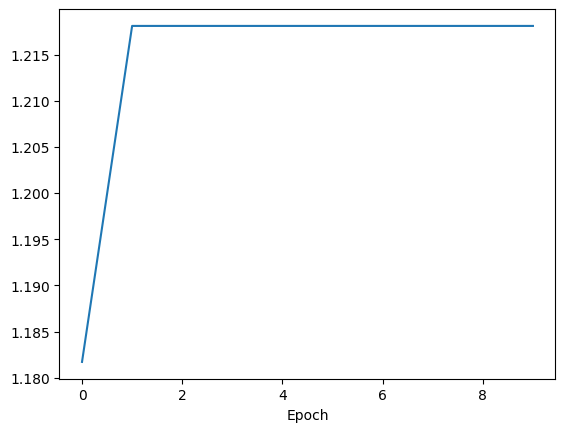

In [39]:
import seaborn as sns

plt.plot(np.array( losses ))
plt.xlabel("Epoch")

In [40]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
